In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
dataset = load_dataset("scikit-learn/iris")

df = pd.DataFrame(dataset['train'])
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Iris.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/150 [00:00<?, ? examples/s]

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [ ]:
X = df.drop("Species", axis=1)
y = df["Species"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
y_pred_dt = dt.predict(X_test)

print("=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

=== Decision Tree ===
Accuracy: 1.0

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 1.0

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



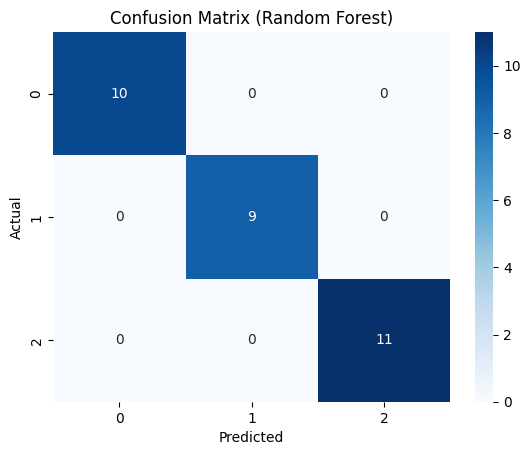

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy
0,Decision Tree,1.0
1,Random Forest,1.0


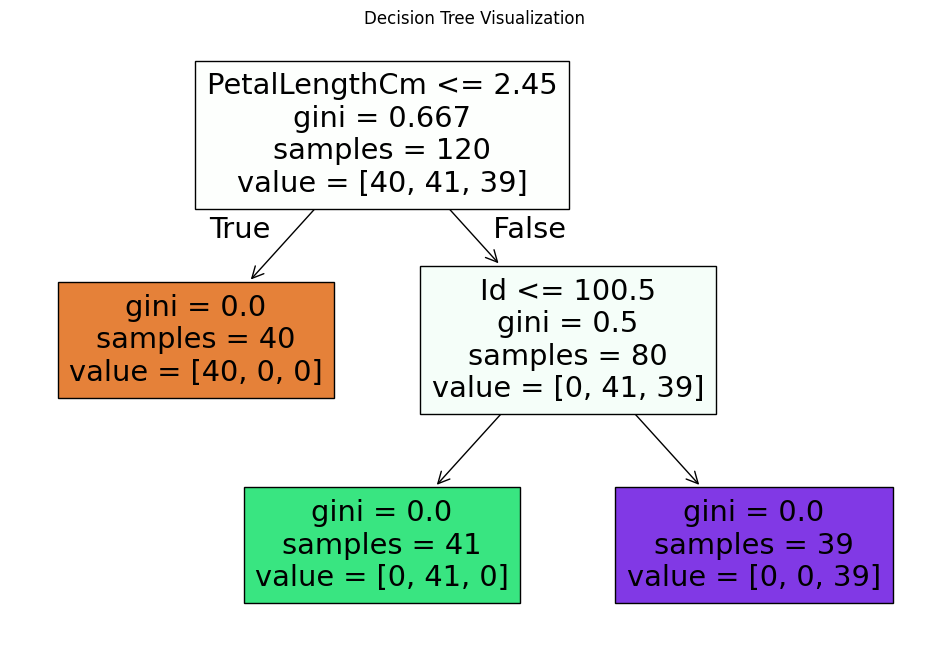

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(dt, filled=True, feature_names=X.columns)
plt.title("Decision Tree Visualization")
plt.show()

## 📝 Decision Tree and Random Forest Classification (Iris Dataset)

This experiment implements Decision Tree and Random Forest classifiers on the Iris dataset (`scikit-learn/iris`) to perform multi-class classification.

---

### 🔹 1. Objective
To apply Decision Tree and Random Forest algorithms for classification and compare their performance.

---

### 🔹 2. Dataset Description
The Iris dataset is a well-known classification dataset containing:
- 150 samples of iris flowers  
- 4 features:
  - sepal length  
  - sepal width  
  - petal length  
  - petal width  
- Target variable (`target`) representing 3 classes:
  - 0 → Setosa  
  - 1 → Versicolor  
  - 2 → Virginica  

---

### 🔹 3. Data Loading and Inspection
The dataset is loaded using Hugging Face and converted into a Pandas DataFrame.  
We use:
- `df.info()` → to check data types and completeness  
- `df.describe()` → to view statistical summary  
- `df.columns` → to identify features and target  

---

### 🔹 4. Feature and Target Selection
- Features (`X`) = all columns except `target`  
- Target (`y`) = `target` column  

---

### 🔹 5. Train-Test Split
The dataset is split into:
- 80% training data  
- 20% testing data  

This ensures that model performance is evaluated on unseen data.

---

### 🔹 6. Decision Tree Classifier
- A Decision Tree model is trained using the training data  
- It works by splitting data based on feature values  
- Each split creates decision rules leading to classification  

Advantages:
- Easy to understand and interpret  
- Requires minimal preprocessing  

Limitations:
- Can overfit if tree is too deep  

---

### 🔹 7. Random Forest Classifier
- Random Forest is an ensemble method using multiple decision trees  
- Each tree is trained on random subsets of data and features  
- Final prediction is based on majority voting  

Advantages:
- Higher accuracy  
- Reduces overfitting  
- More robust than a single decision tree  

---

### 🔹 8. Model Evaluation
Both models are evaluated using:
- **Accuracy Score** → proportion of correct predictions  
- **Classification Report**:
  - Precision → correctness of positive predictions  
  - Recall → ability to find all instances  
  - F1-score → balance between precision and recall  

---

### 🔹 9. Confusion Matrix
- Shows actual vs predicted classifications  
- Helps visualize model performance and errors  

---

### 🔹 10. Model Comparison
- Accuracy of Decision Tree and Random Forest is compared  
- Typically, Random Forest performs better due to ensemble learning  

---

### 🔹 11. Conclusion
- Decision Tree provides a simple and interpretable model  
- Random Forest improves performance by combining multiple trees  
- Ensemble methods like Random Forest are more reliable for classification tasks  

---

### 🧠 Key Learning
- Classification assigns data into predefined categories  
- Decision Trees create rule-based models  
- Random Forest improves accuracy and reduces overfitting  